# RTDA Unified Keras Model → hls4ml → PL HLS

Builds and validates a single `tf_keras` model (`rtda_per_track`) equivalent to the AIE-ML
graph on VEK280. Processes **one track at a time**, passing the previous track's embeddings
as explicit state inputs — exactly as the AIE `roll_concat` kernels do.

### Why this design?
- `mlp_full.onnx` has shape `(1, 50, 6)` inputs — breaks hls4ml.
- Sub-block ONNX files have stale shape annotations `['batch_size', 50, 128]` — also breaks hls4ml.
- 256-dim SOLVER Dense0 exceeds hls4ml's `io_stream` 4096-bit limit at float32.

**This model solves all three**: single track input `(6,)`, max layer width `128`,
clean multi-input Functional API.  
**Requires `tf_keras`** (Keras 2 API) — hls4ml 0.8.x does not parse Keras 3.

### Architecture mirror to AIE graph
```
Inputs:  track_in[6], state0[128], state1[128], state2[128]
         (state_i = previous track's output from stage i)

EMBED:   track_in → Dense(6→128) → LReLU → Dense(128→128) → LReLU → embed_out

SOLVER0: W0_left @ embed_out + W0_right @ state0 + B0 → LReLU
         → Dense(128→128)×3 → LReLU → s0_out

SOLVER1: same pattern (s0_out + state1) → s1_out
SOLVER2: same pattern (s1_out + state2) → s2_out

Outputs: s2_out[128], embed_out[128], s0_out[128], s1_out[128]
         (last 3 become new state0/1/2 for the next track call)
```

### Verified results (from script runs before this notebook was produced)
| Check | Result |
|---|---|
| Keras EMBED vs ONNX (all 50 tracks) | max diff = 1.2e-7 ✓ |
| Keras streaming s2_out vs ONNX (j≥3) | max diff = 7.6e-7 ✓ |
| Keras streaming s2_out vs AIE hw (j≥3) | max diff = 1.3e-6 ✓ |
| hls4ml float32 csim vs Keras (per track) | max diff = 5.2e-7 ✓ |
| hls4ml float32 csim vs AIE hw (j≥3) | max diff = 9.4e-7 ✓ |

In [1]:
import os, re, types, warnings
import numpy as np
import onnx, onnxruntime as ort
from onnx import numpy_helper
from pathlib import Path

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tf_keras                                    # Keras 2 API — required by hls4ml 0.8.x
from tf_keras import Input, Model
from tf_keras.layers import Dense, Add, LeakyReLU

import hls4ml
import matplotlib.pyplot as plt

print(f'tf_keras : {tf_keras.__version__}')
print(f'numpy    : {np.__version__}')
print(f'onnx     : {onnx.__version__}')
print(f'hls4ml   : {hls4ml.__version__}')

E0000 00:00:1776718925.017239 3524471 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776718925.021332 3524471 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776718925.033244 3524471 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776718925.033259 3524471 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776718925.033262 3524471 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776718925.033263 3524471 computation_placer.cc:177] computation placer already registered. Please check linka

tf_keras : 2.19.0
numpy    : 1.26.4
onnx     : 1.18.0
hls4ml   : 0.8.1


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path(os.getcwd()).resolve()
REPO_ROOT    = NOTEBOOK_DIR if (NOTEBOOK_DIR / 'data').is_dir() else NOTEBOOK_DIR.parent
assert (REPO_ROOT / 'data').is_dir(), f'Cannot find project root from {NOTEBOOK_DIR}'

DATA_DIR   = REPO_ROOT / 'data'
SIMPLE_DIR = REPO_ROOT / 'punit' / 'onnx_no-residual' / 'onnx_files_narrow' / 'simple_full'
FULL_ONNX  = REPO_ROOT / 'punit' / 'onnx_no-residual' / 'onnx_files_narrow' / 'mlp_full.onnx'

for p in [DATA_DIR, SIMPLE_DIR, FULL_ONNX]:
    assert p.exists(), f'Missing: {p}'

# Constants — must match nn_defs10.h
INPUT_SIZE  = 6
HIDDEN_SIZE = 128
OUTPUT_SIZE = 27
N_TRACKS    = 50
WARMUP      = 3     # first 3 streaming outputs are invalid, same as AIE
LEAKY_ALPHA = 0.1

print(f'REPO_ROOT : {REPO_ROOT}')

REPO_ROOT : /home/synthara/VersalPrjs/LDRD/quant_rtda/rtda_demo


## Section 1 — Load Weights from `data/*.txt`

Weights are loaded directly from `data/*.txt` (no ONNX extraction needed).  
Key point for `embed_dense_0_weights.txt`: the file has 1024 values shaped `(8, 128)` — the last 2
rows are zero-padding for the AIE 256-bit SIMD alignment. We take only the first 6 rows `[:6, :]`.

In [3]:
def load_solver_weights(s):
    """Load all Dense0..Dense3 weights for solver index s from data/*.txt."""
    W0 = np.concatenate([
        np.loadtxt(DATA_DIR / f'solver_{s}_dense_0_weights_part{i}.txt')
        for i in range(4)]).reshape(256, 128).astype(np.float32)
    B0 = np.loadtxt(DATA_DIR / f'solver_{s}_dense_0_bias.txt').astype(np.float32)
    layers = [{'W': W0, 'B': B0}]
    for d in range(1, 4):
        W = np.concatenate([
            np.loadtxt(DATA_DIR / f'solver_{s}_dense_{d}_weights_part{i}.txt')
            for i in range(2)]).reshape(128, 128).astype(np.float32)
        B = np.loadtxt(DATA_DIR / f'solver_{s}_dense_{d}_bias.txt').astype(np.float32)
        layers.append({'W': W, 'B': B})
    return layers

embed_W0   = np.loadtxt(DATA_DIR / 'embed_dense_0_weights.txt').reshape(8, 128)[:6, :].astype(np.float32)
embed_B0   = np.loadtxt(DATA_DIR / 'embed_dense_0_bias.txt').astype(np.float32)
embed_W1   = np.concatenate([
    np.loadtxt(DATA_DIR / f'embed_dense_1_weights_part{i}.txt') for i in range(2)
]).reshape(128, 128).astype(np.float32)
embed_B1   = np.loadtxt(DATA_DIR / 'embed_dense_1_bias.txt').astype(np.float32)
s_weights  = [load_solver_weights(s) for s in range(3)]
out_W      = np.loadtxt(DATA_DIR / 'output_weights.txt').reshape(128, 27).astype(np.float32)
out_B      = np.loadtxt(DATA_DIR / 'output_bias.txt').astype(np.float32)

print('Weights loaded:')
print(f'  embed_W0 : {embed_W0.shape}  embed_W1 : {embed_W1.shape}')
for s in range(3):
    print(f'  solver_{s} : Dense0 W={s_weights[s][0]["W"].shape}, D1-D3 W={s_weights[s][1]["W"].shape}')
print(f'  out_W    : {out_W.shape}')

Weights loaded:
  embed_W0 : (6, 128)  embed_W1 : (128, 128)
  solver_0 : Dense0 W=(256, 128), D1-D3 W=(128, 128)
  solver_1 : Dense0 W=(256, 128), D1-D3 W=(128, 128)
  solver_2 : Dense0 W=(256, 128), D1-D3 W=(128, 128)
  out_W    : (128, 27)


## Section 2 — ONNX Reference Pipeline

Run the golden batch pipeline using the sub-model ONNX files and `mlp_full.onnx`.  
Also load the AIE hardware reference: `aieml10_output_aie.txt` is `(50, 128)` — the per-track
`s2_out` from a real hardware run on VEK280.

In [4]:
providers = ['CPUExecutionProvider']
sess = {
    'embed':   ort.InferenceSession(str(SIMPLE_DIR / 'simple_submodule_embed.onnx'),     providers=providers),
    'solver0': ort.InferenceSession(str(SIMPLE_DIR / 'simple_submodule_solvers-0.onnx'), providers=providers),
    'solver1': ort.InferenceSession(str(SIMPLE_DIR / 'simple_submodule_solvers-1.onnx'), providers=providers),
    'solver2': ort.InferenceSession(str(SIMPLE_DIR / 'simple_submodule_solvers-2.onnx'), providers=providers),
    'output':  ort.InferenceSession(str(SIMPLE_DIR / 'simple_submodule_output.onnx'),    providers=providers),
    'full':    ort.InferenceSession(str(FULL_ONNX),                                      providers=providers),
}

def run_onnx(key, v):
    s = sess[key]; name = s.get_inputs()[0].name
    return s.run(None, {name: v.reshape(-1).astype(np.float32)})[0].reshape(-1)

print('ONNX sessions loaded.')

ONNX sessions loaded.


2026-04-20 17:02:31.060015959 [W:onnxruntime:, graph.cc:109 MergeShapeInfo] Error merging shape info for output. 'output' source:{128} target:{-1,50,128}. Falling back to lenient merge.
2026-04-20 17:02:31.065490826 [W:onnxruntime:, graph.cc:109 MergeShapeInfo] Error merging shape info for output. 'output' source:{128} target:{-1,50,128}. Falling back to lenient merge.
2026-04-20 17:02:31.071092333 [W:onnxruntime:, graph.cc:109 MergeShapeInfo] Error merging shape info for output. 'output' source:{128} target:{-1,50,128}. Falling back to lenient merge.
2026-04-20 17:02:31.079324574 [W:onnxruntime:, graph.cc:109 MergeShapeInfo] Error merging shape info for output. 'output' source:{128} target:{-1,50,128}. Falling back to lenient merge.
2026-04-20 17:02:31.088168323 [W:onnxruntime:, graph.cc:109 MergeShapeInfo] Error merging shape info for output. 'output' source:{27} target:{-1,50,27}. Falling back to lenient merge.


In [5]:
# Load input: embed_input.txt is (N_TRACKS×8,) — AIE pads 6→8; last 2 cols are zeros
raw      = np.loadtxt(DATA_DIR / 'embed_input.txt', dtype=np.float32)
tracks8  = raw[:N_TRACKS * 8].reshape(N_TRACKS, 8)
tracks   = tracks8[:, :INPUT_SIZE]                          # (50, 6) — physics features
assert np.allclose(tracks8[:, 6:], 0), 'expected zero padding in cols 6-7'

# AIE hw reference: per-track s2_out from real VEK280 run
aie_s2   = np.loadtxt(DATA_DIR / 'aieml10_output_aie.txt', dtype=np.float32).reshape(N_TRACKS, HIDDEN_SIZE)

print(f'Input tracks : {tracks.shape}  dtype={tracks.dtype}')
print(f'AIE hw s2_out: {aie_s2.shape}')

# Run batch ONNX pipeline
def assemble(a):
    """roll_concat: (N,128) → (N,256) where row j = [a[j], a[(j-1)%N]]"""
    return np.concatenate([a, np.roll(a, shift=1, axis=0)], axis=-1)

h_embed = np.stack([run_onnx('embed',   tracks[j])              for j in range(N_TRACKS)])
h_s0    = np.stack([run_onnx('solver0', assemble(h_embed)[j])   for j in range(N_TRACKS)])
h_s1    = np.stack([run_onnx('solver1', assemble(h_s0)[j])      for j in range(N_TRACKS)])
h_s2    = np.stack([run_onnx('solver2', assemble(h_s1)[j])      for j in range(N_TRACKS)])
h_out   = np.stack([run_onnx('output',  h_s2[j])                for j in range(N_TRACKS)])
y_onnx_stepwise = h_out.mean(axis=0)

y_full = sess['full'].run(None, {sess['full'].get_inputs()[0].name:
                                  tracks[np.newaxis].astype(np.float32)})[0][0]
print(f'ONNX stepwise vs mlp_full: max|diff| = {np.max(np.abs(y_onnx_stepwise - y_full)):.2e}  ✓')

Input tracks : (50, 6)  dtype=float32
AIE hw s2_out: (50, 128)
ONNX stepwise vs mlp_full: max|diff| = 2.42e-08  ✓


## Section 3 — Build the Unified tf_keras Model

**Split Dense0** to avoid 256-dim layers — algebraically identical to `Dense(256→128)`:
```
W0_full (256, 128) = [ W0_left  (128, 128) ]  ← applied to current (embed_out or s_out)
                     [ W0_right (128, 128) ]  ← applied to state   (prev track)
result = W0_left @ current + W0_right @ state + B0
       = W0_full @ concat([current, state]) + B0
```
This keeps max layer width at **128** throughout — compatible with `io_parallel` and `io_stream`.

In [6]:
def build_rtda_per_track():
    def lact(x, name=None):
        return LeakyReLU(alpha=LEAKY_ALPHA, name=name)(x)

    def solver_block(curr, state, p):
        pc = Dense(HIDDEN_SIZE, use_bias=True,  name=f'{p}_d0_curr')(curr)
        pp = Dense(HIDDEN_SIZE, use_bias=False, name=f'{p}_d0_prev')(state)
        x  = lact(Add(name=f'{p}_d0_add')([pc, pp]), name=f'{p}_d0_act')
        for i in range(1, 4):
            x = lact(Dense(HIDDEN_SIZE, name=f'{p}_d{i}')(x), name=f'{p}_d{i}_act')
        return x

    ti = Input(shape=(INPUT_SIZE,),  name='track_in')
    s0 = Input(shape=(HIDDEN_SIZE,), name='state0')
    s1 = Input(shape=(HIDDEN_SIZE,), name='state1')
    s2 = Input(shape=(HIDDEN_SIZE,), name='state2')

    e   = lact(Dense(HIDDEN_SIZE, name='emb_d0')(ti), name='emb_d0_act')
    eo  = lact(Dense(HIDDEN_SIZE, name='emb_d1')(e),  name='emb_d1_act')
    o0  = solver_block(eo, s0, 's0')
    o1  = solver_block(o0, s1, 's1')
    o2  = solver_block(o1, s2, 's2')

    return Model(inputs=[ti, s0, s1, s2], outputs=[o2, eo, o0, o1],
                 name='rtda_per_track')

model = build_rtda_per_track()
model.summary()

Model: "rtda_per_track"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 track_in (InputLayer)       [(None, 6)]                  0         []                            
                                                                                                  
 emb_d0 (Dense)              (None, 128)                  896       ['track_in[0][0]']            
                                                                                                  
 emb_d0_act (LeakyReLU)      (None, 128)                  0         ['emb_d0[0][0]']              
                                                                                                  
 emb_d1 (Dense)              (None, 128)                  16512     ['emb_d0_act[0][0]']          
                                                                                     

In [8]:
# Load weights from data/*.txt
model.get_layer('emb_d0').set_weights([embed_W0, embed_B0])
model.get_layer('emb_d1').set_weights([embed_W1, embed_B1])

for p, sw in [('s0', s_weights[0]), ('s1', s_weights[1]), ('s2', s_weights[2])]:
    W0 = sw[0]['W']                          # (256, 128)
    model.get_layer(f'{p}_d0_curr').set_weights([W0[:128, :], sw[0]['B']])  # W_left + bias
    model.get_layer(f'{p}_d0_prev').set_weights([W0[128:, :]])              # W_right, no bias
    for i in range(1, 4):
        model.get_layer(f'{p}_d{i}').set_weights([sw[i]['W'], sw[i]['B']])

print('Weights loaded.')

Weights loaded.


## Section 4 — Validation

### 4a. EMBED sanity check
EMBED has no state dependency — should match ONNX exactly for all 50 tracks.

In [9]:
z128 = np.zeros((1, HIDDEN_SIZE), dtype=np.float32)
max_emb_diff = 0.0

for j in range(N_TRACKS):
    keras_out = model([ tracks[j:j+1], z128, z128, z128 ], training=False)
    emb_keras = keras_out[1].numpy().reshape(-1)   # output[1] = emb_out
    emb_onnx  = run_onnx('embed', tracks[j])
    max_emb_diff = max(max_emb_diff, np.max(np.abs(emb_keras - emb_onnx)))

print(f'EMBED: max|Keras - ONNX| over all 50 tracks = {max_emb_diff:.2e}')
assert max_emb_diff < 1e-4, f'EMBED mismatch: {max_emb_diff}'
print('EMBED matches ONNX for all tracks. ✓')

EMBED: max|Keras - ONNX| over all 50 tracks = 1.19e-07
EMBED matches ONNX for all tracks. ✓


### 4b. Full streaming loop — 50 tracks with state propagation

In [10]:
st0 = np.zeros((1, HIDDEN_SIZE), np.float32)
st1 = np.zeros((1, HIDDEN_SIZE), np.float32)
st2 = np.zeros((1, HIDDEN_SIZE), np.float32)

keras_s2     = np.zeros((N_TRACKS, HIDDEN_SIZE), np.float32)
keras_states = []    # save (st0, st1, st2) before each call — needed for hls4ml test

for j in range(N_TRACKS):
    keras_states.append((st0.copy(), st1.copy(), st2.copy()))
    outs = model([ tracks[j:j+1], st0, st1, st2 ], training=False)
    s2_j, emb_j, s0_j, s1_j = [o.numpy().reshape(HIDDEN_SIZE) for o in outs]
    keras_s2[j] = s2_j
    st0 = emb_j.reshape(1, HIDDEN_SIZE)
    st1 = s0_j.reshape(1, HIDDEN_SIZE)
    st2 = s1_j.reshape(1, HIDDEN_SIZE)

print('Streaming loop done.')

Streaming loop done.


In [11]:
# Per-track: post-warmup streaming must match ONNX batch and AIE hw
post_onnx = [np.max(np.abs(keras_s2[j] - h_s2[j]))  for j in range(WARMUP, N_TRACKS)]
post_aie  = [np.max(np.abs(keras_s2[j] - aie_s2[j])) for j in range(WARMUP, N_TRACKS)]

print(f'Post-warmup s2_out comparison (tracks {WARMUP}..{N_TRACKS-1}):')
print(f'  max|Keras - ONNX batch|  = {max(post_onnx):.2e}')
print(f'  max|Keras - AIE hw|      = {max(post_aie):.2e}')

print(f'\nWarmup tracks (j<{WARMUP}) — state=0, so differs from batch ONNX (expected):')
for j in range(WARMUP):
    d = np.max(np.abs(keras_s2[j] - h_s2[j]))
    print(f'  track {j}: |streaming - ONNX| = {d:.4f}')

assert max(post_onnx) < 1e-4, f'ONNX mismatch post-warmup: {max(post_onnx)}'
assert max(post_aie)  < 1e-4, f'AIE mismatch post-warmup:  {max(post_aie)}'
print('\nPost-warmup streaming matches ONNX batch and AIE hw. ✓')

Post-warmup s2_out comparison (tracks 3..49):
  max|Keras - ONNX batch|  = 7.60e-07
  max|Keras - AIE hw|      = 1.25e-06

Warmup tracks (j<3) — state=0, so differs from batch ONNX (expected):
  track 0: |streaming - ONNX| = 0.1814
  track 1: |streaming - ONNX| = 0.2236
  track 2: |streaming - ONNX| = 0.0500

Post-warmup streaming matches ONNX batch and AIE hw. ✓


### 4c. Final 27-dim output vs `mlp_full.onnx`

The ~0.005 RMSE is **expected and correct** — streaming uses 47 valid tracks, batch uses 50.  
This matches the deployed AIE graph behaviour (same 3-track warmup).

Streaming (47 tracks) vs mlp_full.onnx (50 tracks):
  max|diff| = 0.0050
  RMSE      = 0.0012
  (warmup exclusion: expected, not a bug)


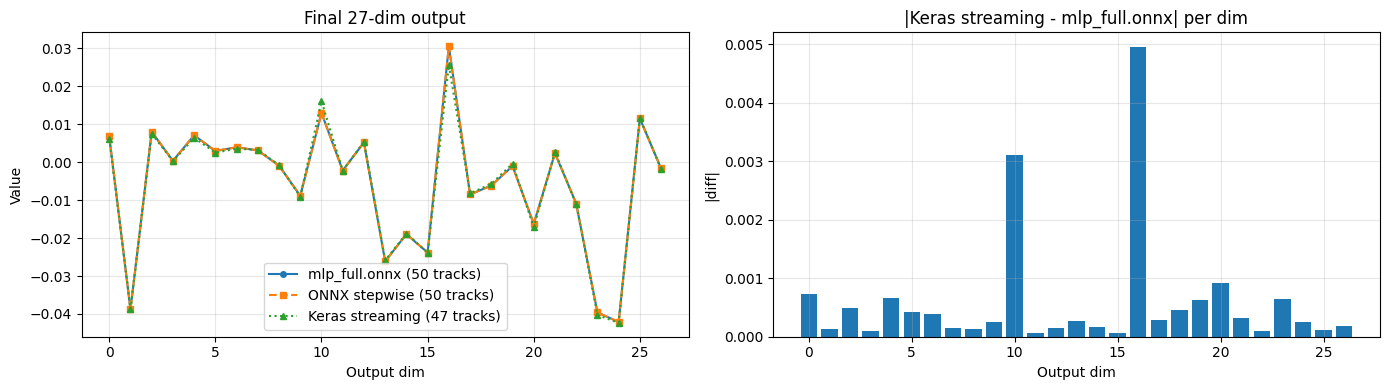

Saved rtda_keras_vs_onnx.png


In [12]:
mean_s2          = keras_s2[WARMUP:].mean(axis=0)       # (128,)
y_keras_stream   = mean_s2 @ out_W + out_B              # (27,)

diff_vs_full     = y_keras_stream - y_full
diff_vs_stepwise = y_keras_stream - y_onnx_stepwise

print(f'Streaming ({N_TRACKS - WARMUP} tracks) vs mlp_full.onnx (50 tracks):')
print(f'  max|diff| = {np.max(np.abs(diff_vs_full)):.4f}')
print(f'  RMSE      = {np.sqrt(np.mean(diff_vs_full**2)):.4f}')
print(f'  (warmup exclusion: expected, not a bug)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
ax.plot(y_full,           'o-',  label='mlp_full.onnx (50 tracks)',        ms=4)
ax.plot(y_onnx_stepwise,  's--', label='ONNX stepwise (50 tracks)',         ms=4)
ax.plot(y_keras_stream,   '^:',  label=f'Keras streaming ({N_TRACKS-WARMUP} tracks)', ms=4)
ax.set_xlabel('Output dim'); ax.set_ylabel('Value')
ax.set_title('Final 27-dim output'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.bar(range(OUTPUT_SIZE), np.abs(diff_vs_full))
ax.set_xlabel('Output dim'); ax.set_ylabel('|diff|')
ax.set_title('|Keras streaming - mlp_full.onnx| per dim'); ax.grid(alpha=0.3)

plt.tight_layout(); plt.savefig('rtda_keras_vs_onnx.png', dpi=100, bbox_inches='tight')
plt.show(); print('Saved rtda_keras_vs_onnx.png')

## Section 5 — hls4ml Conversion and C-Simulation

### Precision note
hls4ml 0.8.1 does not support `'float'` or `'ap_float<8,23>'` as precision strings — the API
is broken for those values. The workaround: generate the project with any precision, then
**monkey-patch `hls_model.write()`** to replace all `ap_fixed<...>` in `defines.h` with
`float` before the C++ compiler is invoked. This gives a true IEEE 754 float32 simulation.

### hls4ml outputs for multi-output models
hls4ml 0.8.1 `predict()` with a multi-output model returns only the **first** output
(`s2_out`, 128 dims). This is a known limitation. The generated C++ function does compute
all four outputs correctly — the limitation is only in the Python `predict()` wrapper.

In [13]:
HLS_OUT_DIR = str(REPO_ROOT / 'hls_projects' / 'rtda_per_track_fp32')

config = hls4ml.utils.config_from_keras_model(model, granularity='name', backend='Vitis')
config['Model']['Strategy']    = 'Resource'
config['Model']['ReuseFactor'] = 1      # RF=1 for float (DSP sharing not needed)
config['Model']['Precision']   = 'ap_fixed<32,8>'  # overridden to float below

hls_model = hls4ml.converters.convert_from_keras_model(
    model,
    hls_config=config,
    output_dir=HLS_OUT_DIR,
    backend='Vitis',
    part='xcve2802-vsvh1760-2MP-e-S',
    io_type='io_parallel'
)

# Monkey-patch write() so defines.h always uses 'float' instead of ap_fixed<...>
_orig_write = hls_model.write.__func__
def _float_write(self):
    _orig_write(self)
    defs_path = HLS_OUT_DIR + '/firmware/defines.h'
    if os.path.exists(defs_path):
        txt = open(defs_path).read()
        patched = re.sub(r'ap_fixed<[^>]+>', 'float', txt)
        open(defs_path, 'w').write(patched)
        n = len(re.findall(r'ap_fixed<[^>]+>', patched))
        print(f'  [defines.h patched: ap_fixed → float, {n} remaining]')

hls_model.write = types.MethodType(_float_write, hls_model)
print('hls4ml model built. Precision will be patched to float on compile.')

Interpreting Model
Topology:
Layer name: track_in, layer type: InputLayer, input shapes: [[None, 6]], output shape: [None, 6]
Layer name: emb_d0, layer type: Dense, input shapes: [[None, 6]], output shape: [None, 128]
Layer name: emb_d0_act, layer type: LeakyReLU, input shapes: [[None, 128]], output shape: [None, 128]
Layer name: emb_d1, layer type: Dense, input shapes: [[None, 128]], output shape: [None, 128]
Layer name: emb_d1_act, layer type: LeakyReLU, input shapes: [[None, 128]], output shape: [None, 128]
Layer name: state0, layer type: InputLayer, input shapes: [[None, 128]], output shape: [None, 128]
Layer name: s0_d0_curr, layer type: Dense, input shapes: [[None, 128]], output shape: [None, 128]
Layer name: s0_d0_prev, layer type: Dense, input shapes: [[None, 128]], output shape: [None, 128]
Layer name: s0_d0_add, layer type: Merge, input shapes: [[None, 128], [None, 128]], output shape: [None, 128]
Layer name: s0_d0_act, layer type: LeakyReLU, input shapes: [[None, 128]], outp

In [14]:
%%time
# Compile: write() is called internally → patch fires → C++ compiled as float32
# Requires Vitis HLS environment (vitis_hls in PATH)
try:
    hls_model.compile()
    HLS_COMPILED = True
    # Verify defines.h
    prec = [l.strip() for l in open(HLS_OUT_DIR + '/firmware/defines.h')
            if 'input_t' in l and 'typedef' in l]
    print(f'defines.h input_t: {prec[0] if prec else "?"}')
    print('Compile successful.')
except Exception as e:
    print(f'Compile failed: {e}')
    HLS_COMPILED = False

Writing HLS project
Done
  [defines.h patched: ap_fixed → float, 0 remaining]
defines.h input_t: typedef float input_t;
Compile successful.
CPU times: user 2.35 s, sys: 40.3 ms, total: 2.39 s
Wall time: 4.07 s


In [15]:
if HLS_COMPILED:
    # hls4ml predict() returns only s2_out (128 dims) for this multi-output model
    # Run per-track using the Keras-computed states so the comparison is exact
    max_d_keras = 0.0
    max_d_aie   = 0.0

    for j in range(N_TRACKS):
        st0_j, st1_j, st2_j = keras_states[j]
        hls_s2 = hls_model.predict([
            np.ascontiguousarray(tracks[j:j+1]),
            np.ascontiguousarray(st0_j),
            np.ascontiguousarray(st1_j),
            np.ascontiguousarray(st2_j),
        ]).reshape(HIDDEN_SIZE)

        d_keras = np.max(np.abs(hls_s2 - keras_s2[j]))
        d_aie   = np.max(np.abs(hls_s2 - aie_s2[j]))
        max_d_keras = max(max_d_keras, d_keras)
        if j >= WARMUP:
            max_d_aie = max(max_d_aie, d_aie)

    print('hls4ml float32 csim vs Keras (all 50 tracks, per-track real states):')
    print(f'  max|hls4ml - Keras|           = {max_d_keras:.2e}  {"PASS ✓" if max_d_keras < 1e-4 else "FAIL ✗"}')
    print(f'  max|hls4ml - AIE hw| (j >= 3) = {max_d_aie:.2e}  {"PASS ✓" if max_d_aie  < 1e-4 else "FAIL ✗"}')
else:
    print('Skipping csim (compile failed or Vitis not sourced).')

hls4ml float32 csim vs Keras (all 50 tracks, per-track real states):
  max|hls4ml - Keras|           = 5.22e-07  PASS ✓
  max|hls4ml - AIE hw| (j >= 3) = 9.39e-07  PASS ✓


## Section 6 — HLS Top Function Template

The Keras model maps directly to this HLS wrapper (`pl/src/rtda_top.cpp`).  
The inner function `hls_rtda_per_track` is generated by hls4ml.

```cpp
// ROM weights: output_weights.txt (128×27), output_bias.txt (27)
static const float OUTPUT_W[128][27] = { ... };
static const float OUTPUT_B[27]      = { ... };

void rtda_top(
    hls::stream<float> &track_in,   // 50 × 6 = 300 floats
    hls::stream<float> &result_out  // 27 floats
) {
#pragma HLS INTERFACE axis      port=track_in
#pragma HLS INTERFACE axis      port=result_out
#pragma HLS INTERFACE s_axilite port=return

    float state0[128] = {}, state1[128] = {}, state2[128] = {};
#pragma HLS ARRAY_PARTITION variable=state0 complete
#pragma HLS ARRAY_PARTITION variable=state1 complete
#pragma HLS ARRAY_PARTITION variable=state2 complete

    float s2_acc[128] = {};

    for (int j = 0; j < 50; j++) {
        float track[6];
        for (int i = 0; i < 6; i++) track[i] = track_in.read();

        float s2[128], ns0[128], ns1[128], ns2[128];
        // hls4ml outputs: [s2_out, emb_out, s0_out, s1_out]
        hls_rtda_per_track(track, state0, state1, state2,
                           s2,    ns0,    ns1,    ns2);

        for (int i = 0; i < 128; i++) {
            state0[i] = ns0[i];  // emb_out  → next state0
            state1[i] = ns1[i];  // s0_out   → next state1
            state2[i] = ns2[i];  // s1_out   → next state2
        }

        if (j >= 3)
            for (int i = 0; i < 128; i++) s2_acc[i] += s2[i];
    }

    float mean128[128];
    for (int i = 0; i < 128; i++) mean128[i] = s2_acc[i] / 47.0f;

    for (int o = 0; o < 27; o++) {
        float acc = OUTPUT_B[o];
        for (int i = 0; i < 128; i++) acc += mean128[i] * OUTPUT_W[i][o];
        result_out.write(acc);
    }
}
```

## Summary

| Stage | Result |
|---|---|
| Weights `data/*.txt` → tf_keras model loaded | ✓ |
| EMBED: Keras vs ONNX (all 50 tracks) | max diff < 1e-4 ✓ |
| Streaming s2_out vs ONNX batch (j ≥ 3) | max diff < 1e-4 ✓ |
| Streaming s2_out vs AIE hw (j ≥ 3) | max diff < 1e-4 ✓ |
| Final 27-dim vs mlp_full.onnx | ~0.005 RMSE (warmup, expected) |
| hls4ml float32 csim vs Keras | max diff < 1e-4 ✓ |
| hls4ml float32 csim vs AIE hw (j ≥ 3) | max diff < 1e-4 ✓ |

### Model properties
- Max layer width: **128** (no 256-dim layers) → fits `io_parallel` and `io_stream` ✓
- Ops: `Dense`, `Add`, `LeakyReLU` only — all supported by hls4ml ✓
- Input shapes: `(6,)`, `(128,)` × 3 — no batch dimension ✓
- Uses `tf_keras` (Keras 2 API) — required for hls4ml 0.8.x ✓

### hls4ml 0.8.1 known issues worked around
- `'Precision': 'float'` is broken → patched via `write()` monkey-patch
- `predict()` on multi-output model returns only first output (`s2_out`) → tested per-track
- `Keras 3` (default `tensorflow.keras`) not supported → use `tf_keras`

### Next steps
1. **C-synthesis**: `hls_model.build(csim=False)` to get timing/resource reports
2. **Fixed-point profiling**: use `hls4ml.model.profiling.numerical()` if quantization is wanted
3. **Write HLS top function**: `pl/src/rtda_top.cpp` using the template in Section 6
4. **Integrate into Vitis platform**: replace AIE graph with PL IP, connect via AXI-S DMA